In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect, text
from IPython.display import display

In [2]:
# Relative path of db
db_path = Path.cwd().parent / "data" / "gas_monitoring.db"

In [3]:
# Convert full path to a string
engine = create_engine(f"sqlite:///{db_path.resolve()}")

In [4]:
# Check if successful
inspector = inspect(engine)
# Check only 1 table
if len(inspector.get_table_names()) == 1:
    print("Table found:", inspector.get_table_names()[0])
    table_name = inspector.get_table_names()[0]
else:
    print("Incorrect amount of tables found")

Table found: gas_monitoring


In [5]:
# Check amount of rows in database
with engine.connect() as connection:
    query = text(f"SELECT COUNT(*) FROM {table_name};")
    db_rows = connection.execute(query).scalar()

print(f" Total rows: {db_rows:,}")

 Total rows: 10,000


In [6]:
# Pull table
df = pd.read_sql_table(table_name, engine)
print(f"Loaded {len(df)} rows into memory.")

Loaded 10000 rows into memory.


In [7]:
df.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

In [10]:
# number of empty cells per column
df.isnull().sum()

Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64

Empty cells are in 4 columns: humidity, metal oxide sensor 2, co gas sensor, and ambient light level

Standardise naming in columns to assist with analysis

In [11]:
# standardise HVAC names to lower case
df["HVAC Operation Mode"] = df["HVAC Operation Mode"].apply(lambda x: x.lower())
df["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
cooling_active      1728
maintenance_mode    1703
eco_mode            1673
heating_active      1660
off                 1652
ventilation_only    1584
Name: count, dtype: int64

In [12]:
# Standardise activity level labels
standardised = {
    'Low Activity': 'low_activity',
    'LowActivity': 'low_activity',
    'Low_Activity': 'low_activity',
    'Moderate Activity': 'moderate_activity',
    'ModerateActivity': 'moderate_activity',
    'High Activity': 'high_activity',
}
df["Activity Level"] = df["Activity Level"].replace(standardised)

In [13]:
def show_null_rows(column_name, df=df):
    """
    Prints the entire row with missing values in the specified column in optionally specified dataframe
    """
    display(df[df[column_name].isna()])

In [14]:
def show_value_counts(condition, df=df):
    """
    Shows the value counts of categorical data when the specified condition is met

    e.g. show_value_counts(df["Temperature"] > 30)
    """
    categorical_columns = [
        "Time of Day",
        "CO_GasSensor",
        "HVAC Operation Mode",
        "Ambient Light Level",
        "Activity Level"
    ]

    filtered_df = df[condition]
    for column_name in categorical_columns:
        print(f"\nValue counts for: {column_name}")
        print(filtered_df[column_name].value_counts(dropna = False))

In [15]:
show_null_rows("Humidity")
show_value_counts(df["Humidity"].isna())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
15,morning,18.53,NaN,80.148375,590.702934,596.654594,765.694890,750.303681,700.075087,0.0,1903,heating_active,very_bright,low_activity
25,afternoon,19.46,NaN,81.850351,616.549883,538.974555,764.222091,488.808765,625.088579,1.0,7241,maintenance_mode,very_dim,low_activity
30,afternoon,20.52,NaN,88.131804,614.973747,506.676587,755.728581,689.985534,611.737822,NaN,7241,cooling_active,bright,moderate_activity
36,afternoon,20.68,NaN,82.119635,618.282123,428.657481,764.534299,718.546551,637.902211,1.0,7241,cooling_active,very_bright,moderate_activity
38,morning,19.64,NaN,139.902168,579.301906,476.971294,720.978887,682.696743,607.577312,1.0,4507,off,dim,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9971,afternoon,17.31,NaN,94.323686,594.188754,461.426538,726.681435,693.159035,628.618046,2.0,2679,cooling_active,None,moderate_activity
9979,night,21.33,NaN,134.623928,553.641599,414.279896,694.386273,651.722779,572.288211,2.0,4761,eco_mode,None,low_activity
9993,morning,16.84,NaN,121.589332,589.097836,502.213084,762.497500,562.849426,669.410300,0.0,5820,eco_mode,bright,low_activity
9995,evening,23.45,NaN,137.854649,544.124855,510.926349,NaN,680.916215,620.292682,1.0,2586,maintenance_mode,very_bright,low_activity



Value counts for: Time of Day
Time of Day
afternoon    524
morning      489
evening      459
night        456
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    907
2.0    528
0.0    244
NaN    157
3.0     78
4.0     14
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
eco_mode            361
cooling_active      329
maintenance_mode    315
heating_active      313
ventilation_only    308
off                 302
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    642
bright         514
moderate       300
None           200
dim            173
very_dim        99
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         1123
moderate_activity     611
high_activity         194
Name: count, dtype: int64


In [16]:
show_null_rows("MetalOxideSensor_Unit2")
show_value_counts(df["MetalOxideSensor_Unit2"].isna())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,None,moderate_activity
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,moderate_activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,low_activity
35,evening,24.02,48.39,128.692361,539.592438,386.797276,NaN,543.856834,477.859881,4.0,7058,maintenance_mode,bright,low_activity
49,afternoon,22.99,51.07,116.780904,532.683719,402.180211,NaN,615.559061,534.378179,4.0,4703,cooling_active,bright,low_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,low_activity
9977,evening,22.85,46.80,119.371474,586.565204,422.759013,NaN,673.232204,625.357845,2.0,9658,maintenance_mode,very_bright,high_activity
9983,afternoon,23.00,152.46,116.846743,577.424852,460.276579,NaN,675.221322,601.178927,1.0,4507,maintenance_mode,moderate,high_activity
9992,evening,22.92,46.64,119.253573,550.549792,495.301121,NaN,685.680572,619.343335,1.0,2586,heating_active,bright,high_activity



Value counts for: Time of Day
Time of Day
evening      382
afternoon    365
morning      345
night        318
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    661
2.0    406
0.0    174
NaN    111
3.0     49
4.0      9
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
maintenance_mode    260
cooling_active      235
eco_mode            233
heating_active      232
off                 229
ventilation_only    221
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    463
bright         418
moderate       195
None           154
dim            121
very_dim        59
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         810
moderate_activity    442
high_activity        158
Name: count, dtype: int64


In [17]:
show_null_rows("CO_GasSensor")
show_value_counts(df["CO_GasSensor"].isna())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,high_activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,low_activity
19,afternoon,19.57,51.23,91.168499,611.561714,537.713012,751.668484,709.823944,621.493028,NaN,7241,maintenance_mode,very_bright,moderate_activity
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,moderate_activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9954,afternoon,293.94,44.55,75.618247,567.044186,511.008803,753.665230,718.474331,664.598081,NaN,2586,eco_mode,very_bright,moderate_activity
9964,afternoon,21.69,44.71,81.385283,561.968352,527.330609,752.324424,718.379962,659.181524,NaN,2586,heating_active,very_dim,low_activity
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,low_activity
9980,night,292.01,52.10,118.519591,587.887196,464.160197,748.870053,712.972441,642.839403,NaN,9658,off,very_bright,moderate_activity



Value counts for: Time of Day
Time of Day
afternoon    247
night        201
evening      197
morning      189
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
NaN    834
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
off                 155
ventilation_only    147
heating_active      137
eco_mode            134
maintenance_mode    131
cooling_active      130
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    284
bright         244
moderate       119
None            75
dim             66
very_dim        46
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         492
moderate_activity    252
high_activity         90
Name: count, dtype: int64


In [18]:
show_null_rows("Ambient Light Level")
show_value_counts(df["Ambient Light Level"].isna())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,low_activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,low_activity
11,afternoon,19.71,48.68,80.161332,615.972458,575.491588,780.078308,732.349009,667.927995,0.0,7241,eco_mode,None,moderate_activity
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,None,moderate_activity
17,afternoon,19.73,50.62,91.736107,619.342912,527.869881,761.418621,703.674613,618.386499,0.0,7241,heating_active,None,high_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,low_activity
9971,afternoon,17.31,NaN,94.323686,594.188754,461.426538,726.681435,693.159035,628.618046,2.0,2679,cooling_active,None,moderate_activity
9976,night,20.99,57.61,-9.992761,561.460188,446.620844,703.945003,663.041519,578.163559,1.0,4761,maintenance_mode,None,low_activity
9979,night,21.33,NaN,134.623928,553.641599,414.279896,694.386273,651.722779,572.288211,2.0,4761,eco_mode,None,low_activity



Value counts for: Time of Day
Time of Day
afternoon    289
morning      271
evening      252
night        242
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    498
2.0    280
0.0    139
NaN     75
3.0     53
4.0      9
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
cooling_active      189
ventilation_only    181
heating_active      179
maintenance_mode    179
eco_mode            173
off                 153
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
None    1054
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         572
moderate_activity    362
high_activity        120
Name: count, dtype: int64


Initial inspection of missing values do not show any obvious reasons, will examine non-missing data first before deciding on what to do

In [19]:
# number of duplicate rows
df.duplicated().sum()

265

In [20]:
# inspect duplicate rows
display(df[df.duplicated()])
show_value_counts(df.duplicated())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
493,evening,23.52,43.25,88.690954,603.702902,496.306607,747.498224,702.297867,630.522057,1.0,5693,heating_active,bright,moderate_activity
781,evening,24.84,44.60,96.529946,601.441014,467.984406,726.750458,692.238127,599.940848,1.0,9127,eco_mode,very_bright,moderate_activity
1097,morning,18.99,55.92,118.637160,600.695160,502.885955,735.720000,703.310462,615.349296,1.0,5693,ventilation_only,bright,high_activity
1252,evening,24.06,44.04,105.264563,598.388502,496.349041,735.360708,703.337182,629.341589,1.0,8374,off,moderate,moderate_activity
1423,morning,18.05,45.57,67.096257,624.539435,573.052050,782.076193,756.024200,707.783323,0.0,1482,heating_active,very_dim,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9900,afternoon,24.45,47.66,112.213544,549.766466,402.473680,731.491427,672.209675,619.458403,1.0,4703,heating_active,bright,low_activity
9902,night,18.08,54.39,118.473630,587.984997,506.368702,739.635625,698.921105,617.032041,1.0,9658,cooling_active,moderate,low_activity
9910,night,20.87,57.48,134.531336,560.602244,437.401852,699.683996,651.971387,598.752654,1.0,4761,maintenance_mode,bright,low_activity
9946,evening,25.70,48.15,121.606097,539.641062,484.896859,675.467858,594.954642,537.075883,2.0,6817,maintenance_mode,moderate,moderate_activity



Value counts for: Time of Day
Time of Day
afternoon    75
morning      70
evening      64
night        56
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    140
2.0     72
0.0     33
3.0     10
NaN      5
4.0      5
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
eco_mode            50
heating_active      47
maintenance_mode    47
cooling_active      45
off                 39
ventilation_only    37
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    100
bright          71
moderate        47
very_dim        22
dim             21
None             4
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         157
moderate_activity     78
high_activity         30
Name: count, dtype: int64


Duplicate rows seem to be duplicated at random

In [21]:
# remove duplicate rows
df.drop_duplicates(inplace=True)
df.shape

(9735, 14)

Moving on to inspection of values in individual columns

Time of Day Column

In [22]:
# values in time of day column
df["Time of Day"].value_counts()

Time of Day
afternoon    2560
evening      2412
morning      2390
night        2373
Name: count, dtype: int64

Temperature Column (WIP)

In [23]:
def plot_scatter(values, x_axis=None):
    """
    Plots a scatter graph of values
    Uses x axis if provided, otherwise defaults to the index of the values
    """
    plt.figure(figsize=(10, 5))
    # if no x_axis is provided, use list index
    x = x_axis if x_axis is not None else range(len(values))
    plt.scatter(x, values, alpha=0.7)
    plt.grid(True, alpha=0.3)
    plt.show()

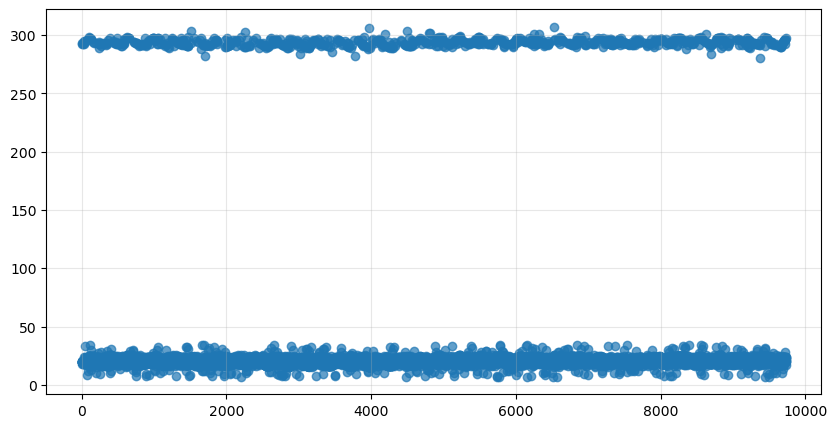

count    9735.000000
mean       42.803388
std        74.843975
min         6.903485
25%        18.930000
50%        20.510000
75%        23.190000
max       307.070000
Name: Temperature, dtype: float64

In [24]:
# Visualise and show distribution of temperature readings
plot_scatter(df["Temperature"])
df["Temperature"].describe()

min and max values are abnormal

In [25]:
# inspect abnormally high values
high_temp_values = df[df["Temperature"] > 50]
high_temp_values

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,low_activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,low_activity
24,afternoon,292.65,51.95,84.581085,617.316915,534.905951,767.204960,717.770588,617.513808,1.0,7241,eco_mode,very_bright,moderate_activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,moderate_activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,low_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9980,night,292.01,52.10,118.519591,587.887196,464.160197,748.870053,712.972441,642.839403,NaN,9658,off,very_bright,moderate_activity
9981,evening,295.61,45.84,85.732048,559.357007,511.585673,749.994773,704.264333,647.845091,1.0,2586,eco_mode,moderate,moderate_activity
9982,evening,295.67,45.89,91.771848,552.961200,515.944782,751.423006,713.109219,653.457688,1.0,2586,maintenance_mode,very_dim,high_activity
9989,night,296.17,49.35,119.874350,571.897844,413.811232,711.960225,673.048526,589.516066,2.0,1826,ventilation_only,None,low_activity


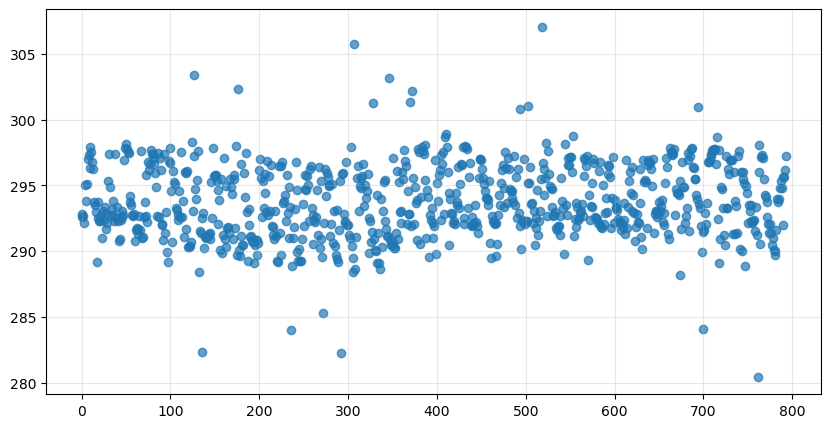

count    794.000000
mean     293.760327
std        2.791111
min      280.450000
25%      291.917500
50%      293.360000
75%      295.870000
max      307.070000
Name: Temperature, dtype: float64

In [26]:
# visualise temperature above 50
plot_scatter(high_temp_values["Temperature"])
high_temp_values["Temperature"].describe()

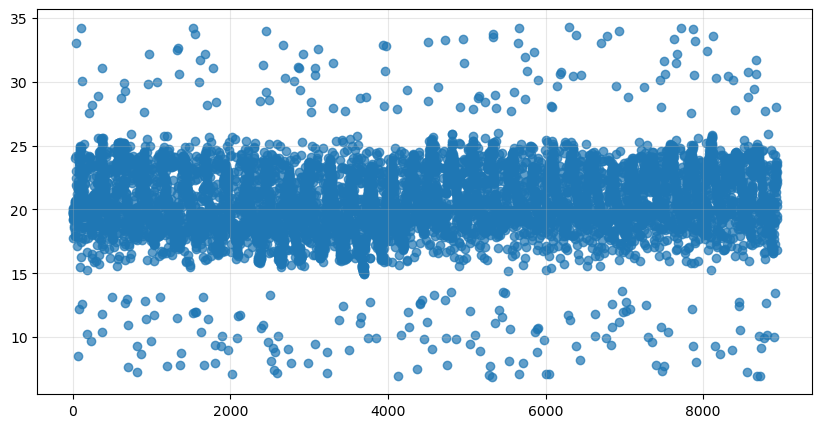

In [27]:
# visualise the rest of the temperature data
plot_scatter(df[df["Temperature"] < 50]["Temperature"])

If assuming that the abnormally high temperatures have been multiplied by 10

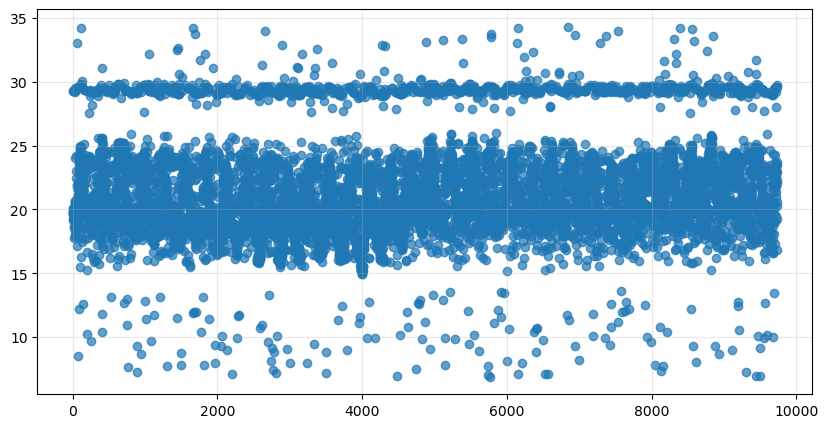

In [28]:
# make a copy to test hypothesis
testing_df = df.copy()
# divide high temperatures by 10
testing_df.loc[testing_df['Temperature'] > 50, 'Temperature'] /= 10
# visualise
plot_scatter(testing_df["Temperature"])

If assuming that the abnormally high temperature values are in Kelvin

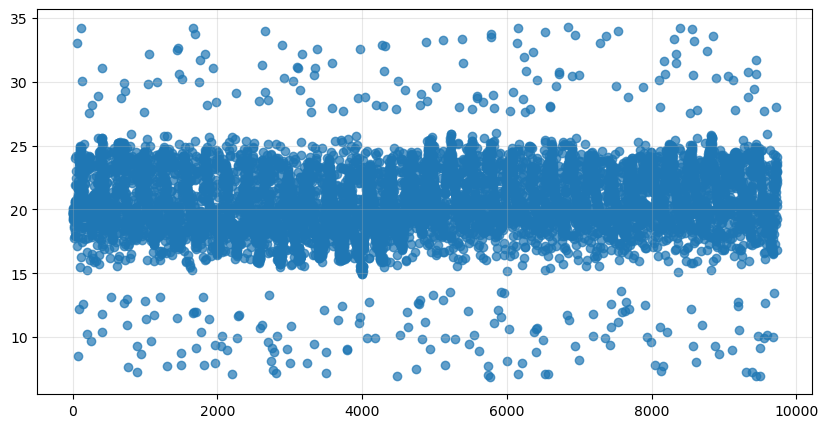

In [29]:
# make a copy to test hypothesis
testing_df = df.copy()
# minus high temperature by 273.15
testing_df.loc[testing_df['Temperature'] > 50, 'Temperature'] -= 273.15
# visualise
plot_scatter(testing_df["Temperature"])

Between the two assumptions, assuming that the abnormally high temperature values are in Kelvin and correcting them produces temperature values that are consistent with the rest of the data. Therefore, it will be assumed that the high values were recorded in Kelvin

In [30]:
# applying the same change to the original dataframe
df.loc[df['Temperature'] > 50, 'Temperature'] -= 273.15

In [31]:
# inspect high temperature values
display(df[df["Temperature"] > 30])
show_value_counts(df["Temperature"] > 30)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
54,morning,33.041318,51.67,105.630998,596.534869,486.448341,747.038731,712.401956,628.500943,1.0,8374,cooling_active,moderate,high_activity
111,evening,34.239708,NaN,118.441217,595.729435,452.272956,723.133913,485.407246,592.647198,2.0,7241,maintenance_mode,very_bright,low_activity
133,evening,30.060079,52.67,118.153494,599.747325,421.326002,711.865910,652.665558,591.103827,3.0,7241,eco_mode,very_bright,low_activity
407,afternoon,31.100551,52.83,118.288369,552.688992,462.830697,681.298560,600.175993,544.795447,2.0,7058,heating_active,None,low_activity
1055,evening,32.197490,47.23,105.385537,591.210696,474.922904,739.474129,684.811562,611.941445,1.0,9658,eco_mode,very_bright,low_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9291,afternoon,30.466123,52.05,117.532450,539.323051,474.100402,711.941508,669.027852,602.710548,2.0,1458,cooling_active,very_bright,low_activity
9358,afternoon,30.142086,125.88,116.780904,532.683719,402.180211,705.410192,615.559061,534.378179,4.0,4703,cooling_active,bright,low_activity
9579,morning,30.779348,50.17,100.064692,550.161557,458.934474,725.118787,639.296548,574.862978,2.0,4703,off,very_bright,low_activity
9691,evening,31.677019,48.76,103.291036,551.113497,443.834025,732.176971,688.450618,617.830907,1.0,4703,ventilation_only,bright,moderate_activity



Value counts for: Time of Day
Time of Day
morning      25
afternoon    18
evening      14
night        14
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    38
2.0    17
0.0     7
NaN     5
3.0     2
4.0     2
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
cooling_active      17
off                 14
maintenance_mode    13
ventilation_only    11
eco_mode             8
heating_active       8
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
bright         24
very_bright    20
moderate        9
dim             8
None            5
very_dim        5
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         44
moderate_activity    17
high_activity        10
Name: count, dtype: int64


In [32]:
# inspect low temperature values
df[df["Temperature"] < 15]
show_value_counts(df["Temperature"] < 15)


Value counts for: Time of Day
Time of Day
morning      44
afternoon    39
evening      36
night        36
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    79
2.0    35
0.0    23
NaN    11
3.0     6
4.0     1
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
heating_active      31
off                 28
eco_mode            28
maintenance_mode    28
ventilation_only    22
cooling_active      18
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    62
bright         41
moderate       17
None           16
very_dim       12
dim             7
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         84
moderate_activity    53
high_activity        18
Name: count, dtype: int64


Humidity Column (WIP)

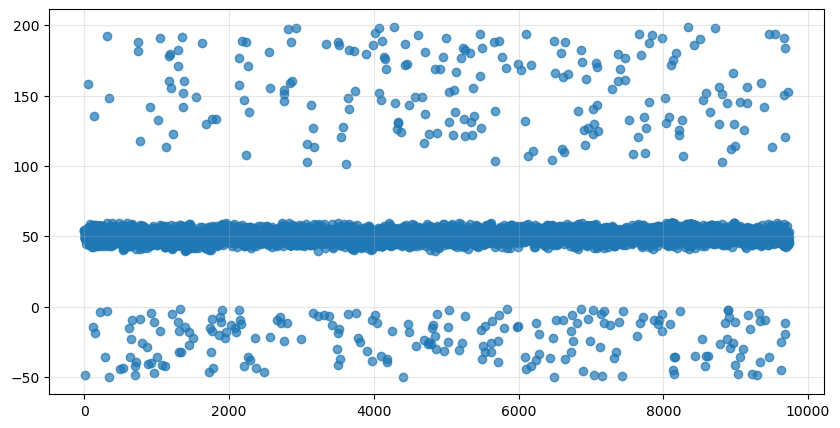

count    7824.000000
mean       51.666240
std        21.657642
min       -49.870000
25%        47.647500
50%        51.390000
75%        53.850000
max       198.900000
Name: Humidity, dtype: float64

In [33]:
# Visualise and show distribution of humidity readings
plot_scatter(df["Humidity"])
df["Humidity"].describe()

Values above 100 and below 0 are impossible for humidity percentage

In [34]:
# inspect abnormal values
display(df[(df["Humidity"] > 100) | (df["Humidity"] < 0)])
show_value_counts((df["Humidity"] > 100) | (df["Humidity"] < 0))

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,low_activity
50,afternoon,20.19,158.33,89.470910,620.364794,405.071346,747.384712,698.477480,621.003407,1.0,7241,heating_active,None,low_activity
120,night,18.57,-14.79,121.184923,579.703970,468.239926,NaN,678.065464,620.466497,1.0,2679,cooling_active,very_bright,moderate_activity
128,evening,22.73,135.21,125.466163,591.519617,414.920829,714.063935,660.222162,578.452856,3.0,7241,heating_active,very_bright,low_activity
146,night,19.69,-18.73,120.017584,549.422635,459.086470,692.412305,645.741758,571.745341,2.0,7058,off,bright,low_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9942,afternoon,18.67,183.84,180.176445,572.653896,563.034853,781.939704,728.174809,697.167548,0.0,2586,maintenance_mode,very_bright,low_activity
9945,afternoon,19.09,-11.60,73.710835,572.395364,548.852905,781.012720,743.040666,680.972017,0.0,2586,eco_mode,bright,moderate_activity
9947,afternoon,20.29,-19.31,78.494846,560.663225,428.938003,741.508039,690.496168,645.853640,0.0,2586,off,bright,low_activity
9950,afternoon,20.84,120.33,68.815941,566.245679,484.518300,754.121435,708.360447,666.830387,1.0,2586,off,very_bright,low_activity



Value counts for: Time of Day
Time of Day
afternoon    117
night        104
evening      103
morning       90
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    192
2.0    123
0.0     47
NaN     36
3.0     11
4.0      5
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
cooling_active      83
off                 73
maintenance_mode    70
ventilation_only    68
heating_active      63
eco_mode            57
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    146
bright         106
moderate        63
dim             40
None            39
very_dim        20
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         262
moderate_activity    114
high_activity         38
Name: count, dtype: int64


In [35]:
# Remove outliers by setting them to NaN
df.loc[(df["Humidity"] > 100) | (df["Humidity"] < 0), "Humidity"] = np.nan

Identifying correlation between variables using rows with no missing data

In [36]:
# create a dataframe without any missing values
valid_df = df.copy().dropna()

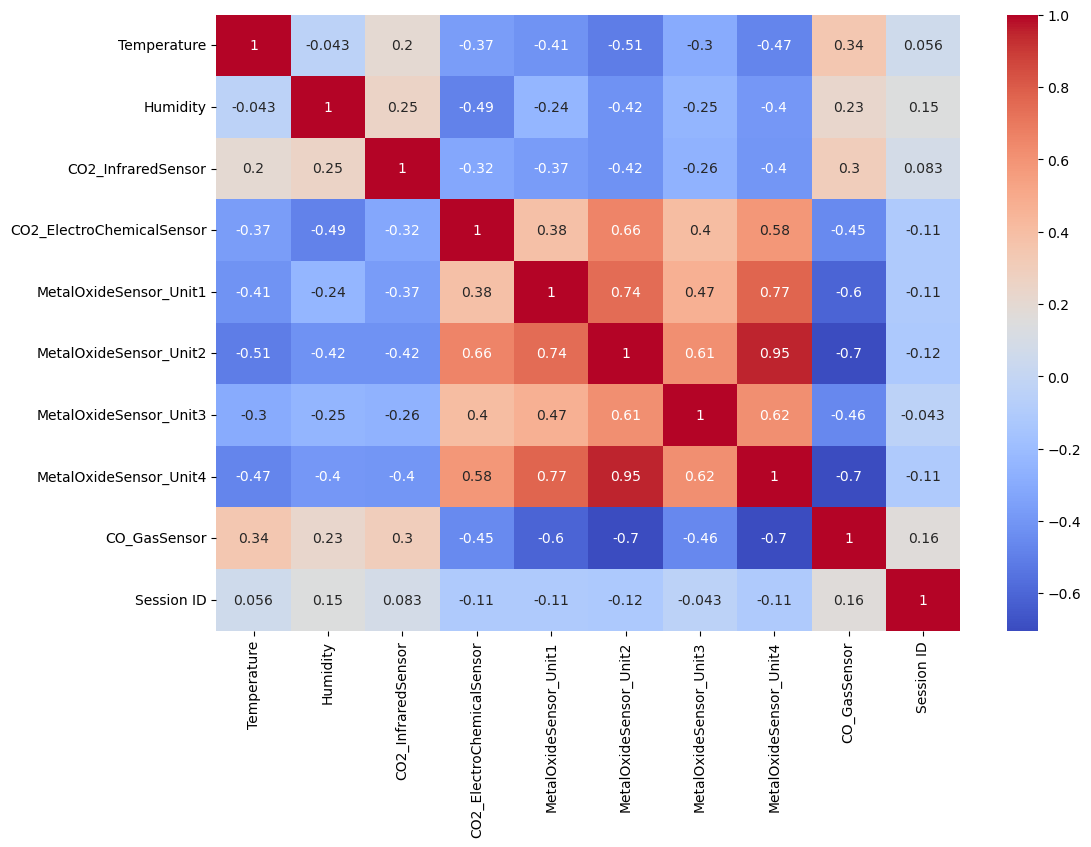

In [37]:
# calculate correlation between columns with numeric data
numeric_corr = valid_df.corr(numeric_only=True)

# visualise correlation
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_corr, annot=True, cmap="coolwarm")
plt.show()

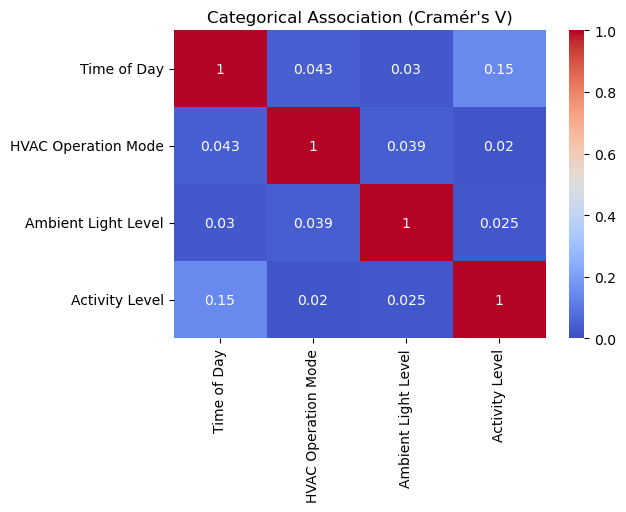

In [38]:
from scipy.stats import chi2_contingency

# function for calculating correlation between categorical data
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# identify columns with categorical data
categorical_columns = ["Time of Day", "HVAC Operation Mode", "Ambient Light Level", "Activity Level"]

#create matrix
corr_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

# iterate and calculate correlation between the columns
for col1 in categorical_columns:
    for col2 in categorical_columns:
        corr_matrix.loc[col1, col2] = cramers_v(valid_df[col1], valid_df[col2])

categorical_corr = corr_matrix.astype(float)

plt.figure(figsize=(6, 4))
sns.heatmap(categorical_corr, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Categorical Association (Cramér's V)")
plt.show()

In [39]:
from scipy.stats import f_oneway

def eta_squared(categories, values):
    categories = pd.Categorical(categories)

    groups = [
        values[categories == cat]
        for cat in categories.categories
    ]

    overall_mean = np.mean(values)

    # between columns sum of square difference
    ss_between = sum(
        len(group) * (np.mean(group) - overall_mean) ** 2
        for group in groups
    )

    # total sum of squares
    ss_total = sum((values - overall_mean) ** 2)

    return ss_between / ss_total

In [40]:
numerical_columns = [
    "Temperature",
    "Humidity",
    "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4",
    "CO_GasSensor",
    "Session ID"
]

In [41]:
results = pd.DataFrame(index=categorical_columns, columns=numerical_columns)

for cat in categorical_columns:
    for num in numerical_columns:
        results.loc[cat, num] = eta_squared(
            valid_df[cat],
            valid_df[num]
        )

results = results.astype(float)

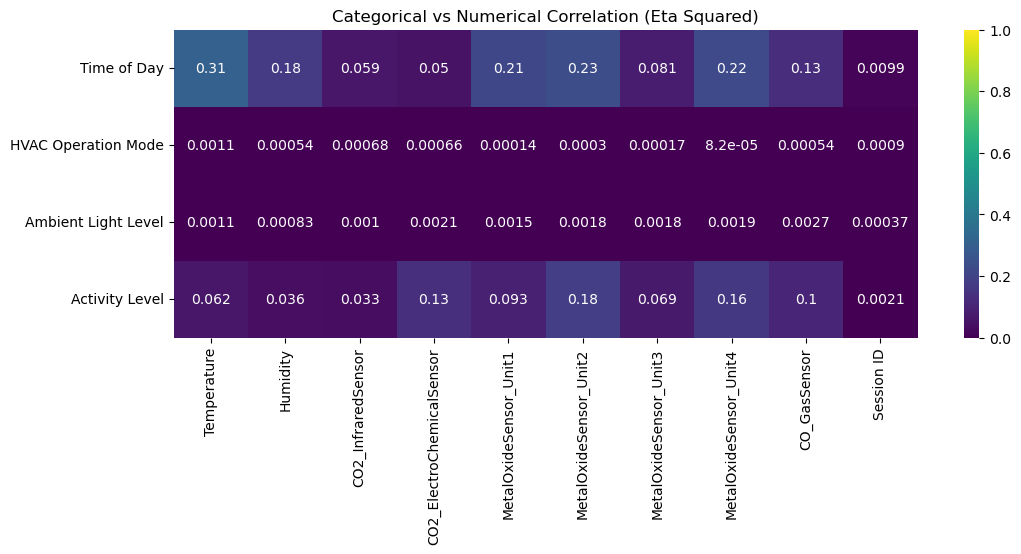

In [42]:
plt.figure(figsize=(12, 4))

sns.heatmap(
    results,
    annot=True,
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.title("Categorical vs Numerical Correlation (Eta Squared)")
plt.show()

Based on correlation analysis, Session ID is not correlated with any of the other data. This means that the different sessions produced data that are varied.

CO2_InfraredSensor Column (WIP)

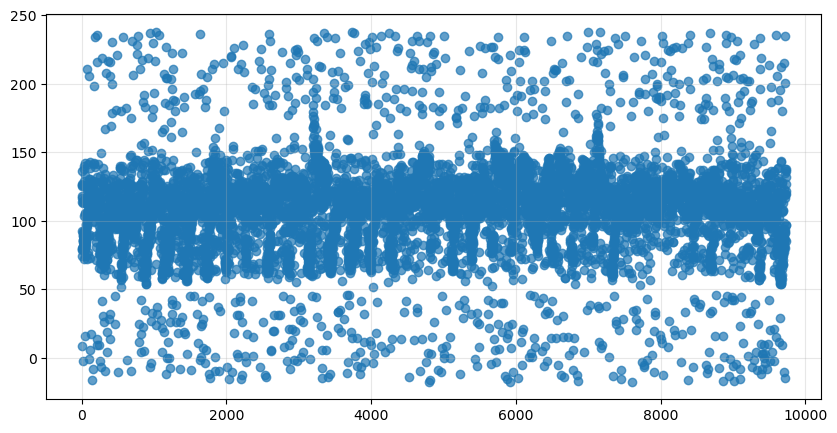

count    9735.000000
mean      109.838539
std        34.088211
min       -17.472184
25%        96.492723
50%       112.815058
75%       124.563132
max       237.873938
Name: CO2_InfraredSensor, dtype: float64

In [43]:
plot_scatter(df["CO2_InfraredSensor"])
df["CO2_InfraredSensor"].describe()

In [44]:
df[(df["CO2_InfraredSensor"] > 200) | (df["CO2_InfraredSensor"] < 0)]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,moderate_activity
81,morning,19.81,58.73,210.936386,550.024240,497.946800,NaN,600.784988,541.389787,NaN,8936,heating_active,bright,low_activity
100,morning,15.48,42.19,205.484167,605.228667,582.396453,787.194813,754.069349,704.616559,1.0,8052,cooling_active,moderate,low_activity
101,evening,24.94,46.56,-1.146669,605.868070,475.340247,726.618627,681.717422,598.765948,1.0,7241,off,moderate,moderate_activity
143,morning,19.54,55.70,-16.122085,562.727918,475.855521,738.540879,691.220608,634.500030,1.0,2847,cooling_active,bright,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,low_activity
9976,night,20.99,57.61,-9.992761,561.460188,446.620844,703.945003,663.041519,578.163559,1.0,4761,maintenance_mode,None,low_activity
9984,evening,23.48,44.08,200.468863,562.455946,527.358322,747.075654,709.220197,647.675453,1.0,2586,eco_mode,moderate,low_activity
9986,evening,23.16,44.96,-15.001692,559.858738,505.954916,743.344164,692.204081,631.571948,1.0,2586,off,very_bright,low_activity


Cross reference infrared sensor with electrochemical sensor

CO2_ElectroChemicalSensor Column (WIP)

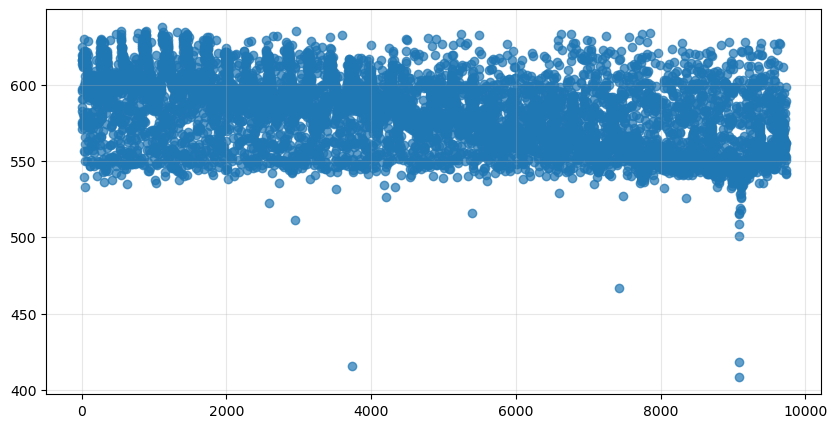

count    9735.000000
mean      578.624225
std        22.587891
min       408.599386
25%       559.336038
50%       579.351176
75%       595.578474
max       637.895790
Name: CO2_ElectroChemicalSensor, dtype: float64

In [45]:
plot_scatter(df["CO2_ElectroChemicalSensor"])
df["CO2_ElectroChemicalSensor"].describe()

MetalOxideSensor_Unit1 Column (WIP)

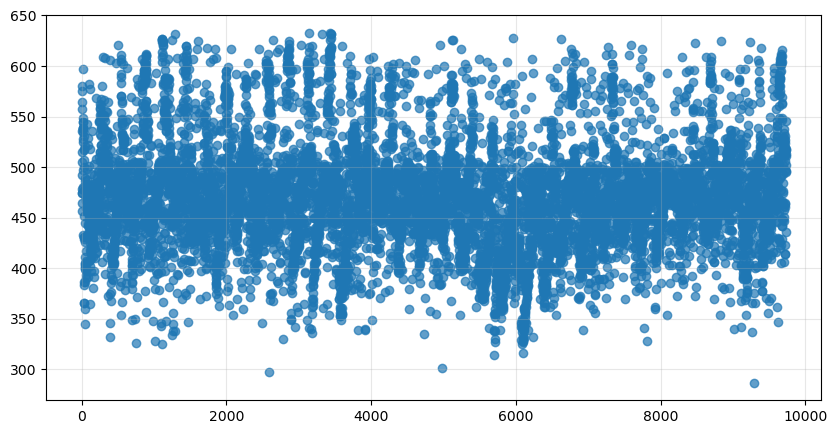

count    9735.000000
mean      471.025216
std        51.454466
min       286.825662
25%       440.268421
50%       469.244105
75%       494.765605
max       632.891693
Name: MetalOxideSensor_Unit1, dtype: float64

In [46]:
plot_scatter(df["MetalOxideSensor_Unit1"])
df["MetalOxideSensor_Unit1"].describe()

MetalOxideSensor_Unit2 Column (WIP)

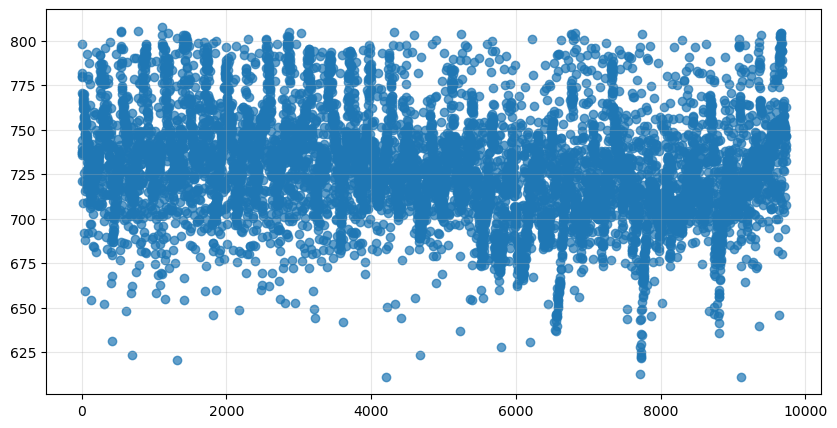

count    8333.000000
mean      728.408947
std        29.154791
min       611.168916
25%       709.678072
50%       726.784531
75%       745.033909
max       807.732943
Name: MetalOxideSensor_Unit2, dtype: float64

In [47]:
plot_scatter(df["MetalOxideSensor_Unit2"])
df["MetalOxideSensor_Unit2"].describe()

MetalOxideSensor_Unit3 Column (WIP)

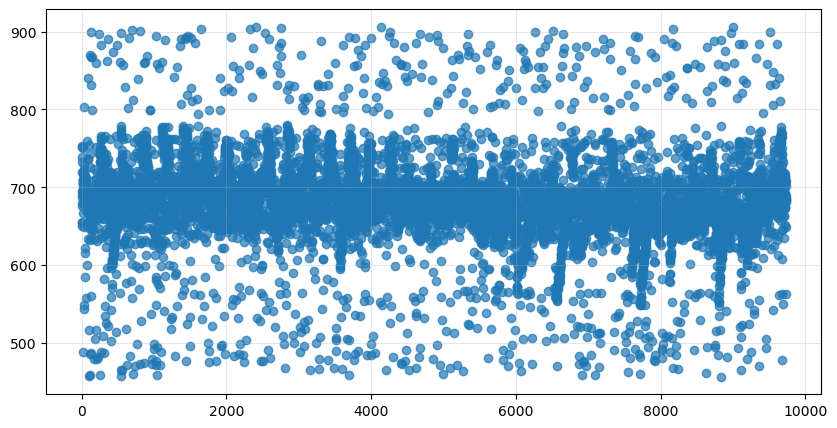

count    9735.000000
mean      680.487947
std        56.361618
min       456.673900
25%       658.474815
50%       679.847421
75%       703.680497
max       906.213097
Name: MetalOxideSensor_Unit3, dtype: float64

In [48]:
plot_scatter(df["MetalOxideSensor_Unit3"])
df["MetalOxideSensor_Unit3"].describe()

MetalOxideSensor_Unit4 Column (WIP)

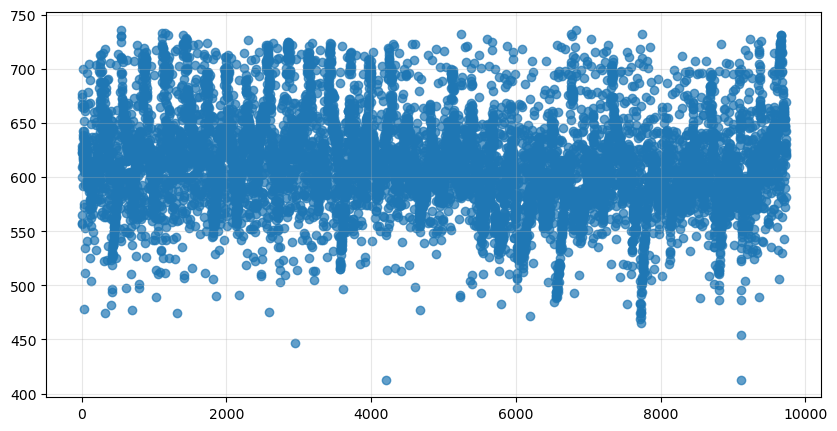

count    9735.000000
mean      612.264375
std        43.166075
min       412.791904
25%       585.367474
50%       609.514533
75%       636.161382
max       736.112361
Name: MetalOxideSensor_Unit4, dtype: float64

In [49]:
plot_scatter(df["MetalOxideSensor_Unit4"])
df["MetalOxideSensor_Unit4"].describe()

CO_GasSensor Column (WIP)

In [50]:
df["CO_GasSensor"].value_counts(dropna=False)

CO_GasSensor
1.0    4582
2.0    2676
0.0    1158
NaN     829
3.0     420
4.0      70
Name: count, dtype: int64

Session ID Column

In [51]:
df["Session ID"].value_counts()

Session ID
6528    379
4703    375
3418    356
1374    350
5820    349
7058    336
3592    335
2105    335
2847    330
3856    326
8936    304
7395    299
1903    297
4507    291
1826    275
9385    272
2679    269
9658    259
4129    253
5693    246
9127    242
8052    237
7241    237
6431    237
9184    234
9241    232
3074    230
7963    225
8374    207
6817    192
5172    191
1458    175
4761    174
6847    170
5214    165
1482    156
8649    139
2586     56
Name: count, dtype: int64

HVAC Operation Mode Column

In [52]:
df["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
cooling_active      1683
maintenance_mode    1656
eco_mode            1623
off                 1613
heating_active      1613
ventilation_only    1547
Name: count, dtype: int64

Ambient Light Level Column (WIP)

In [53]:
df["Ambient Light Level"].value_counts(dropna=False)

Ambient Light Level
very_bright    3287
bright         2626
moderate       1416
None           1050
dim             843
very_dim        513
Name: count, dtype: int64

Activity Level Column

In [54]:
df[df["Ambient Light Level"].isna()]["Time of Day"].value_counts()

Time of Day
afternoon    287
morning      271
evening      251
night        241
Name: count, dtype: int64

In [55]:
df["Activity Level"].value_counts()

Activity Level
low_activity         5610
moderate_activity    3060
high_activity        1065
Name: count, dtype: int64